In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, roc_curve

In [2]:
df = pd.read_csv("dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (30000, 12)


In [3]:
df.head()

,patient_id,age,gender,blood_pressure,cholesterol,bmi,diabetes,hypertension,medication_count,length_of_stay,discharge_destination,readmitted_30_days
0,1,74,Other,130/72,240,31.5,Yes,No,5,1,Nursing_Facility,Yes
1,2,46,Female,120/92,292,36.3,No,No,4,3,Nursing_Facility,No
2,3,89,Other,135/78,153,30.3,No,Yes,1,1,Home,No
3,4,84,Female,123/80,153,31.5,No,Yes,3,10,Home,No
4,5,32,Other,135/84,205,18.4,No,Yes,6,4,Nursing_Facility,No


In [4]:
# Dataset me kaun-kaun se columns hain aur unka data type kya hai, ye check kar rahe hain
print(df.columns.tolist())
print("\nData Types:")
print(df.dtypes)

['patient_id', 'age', 'gender', 'blood_pressure', 'cholesterol', 'bmi', 'diabetes', 'hypertension', 'medication_count', 'length_of_stay', 'discharge_destination', 'readmitted_30_days']

Data Types:
patient_id                 int64
age                        int64
gender                       str
blood_pressure               str
cholesterol                int64
bmi                      float64
diabetes                     str
hypertension                 str
medication_count           int64
length_of_stay             int64
discharge_destination        str
readmitted_30_days           str
dtype: object


In [5]:
# Dataset me koi value missing to nahi hai, ye check kar rahe hain
print(df.isnull().sum())

patient_id               0
age                      0
gender                   0
blood_pressure           0
cholesterol              0
bmi                      0
diabetes                 0
hypertension             0
medication_count         0
length_of_stay           0
discharge_destination    0
readmitted_30_days       0
dtype: int64


In [6]:
# Dataset ka size aur overall information ek baar dekh rahe hain
print("Rows, Columns:", df.shape)
print("\nDataset Info:")
df.info()

Rows, Columns: (30000, 12)

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   patient_id             30000 non-null  int64  
 1   age                    30000 non-null  int64  
 2   gender                 30000 non-null  str    
 3   blood_pressure         30000 non-null  str    
 4   cholesterol            30000 non-null  int64  
 5   bmi                    30000 non-null  float64
 6   diabetes               30000 non-null  str    
 7   hypertension           30000 non-null  str    
 8   medication_count       30000 non-null  int64  
 9   length_of_stay         30000 non-null  int64  
 10  discharge_destination  30000 non-null  str    
 11  readmitted_30_days     30000 non-null  str    
dtypes: float64(1), int64(5), str(6)
memory usage: 2.7 MB


In [7]:
# Dataset me target/readmission wala column identify kar rahe hain
print(df.columns.tolist())

['patient_id', 'age', 'gender', 'blood_pressure', 'cholesterol', 'bmi', 'diabetes', 'hypertension', 'medication_count', 'length_of_stay', 'discharge_destination', 'readmitted_30_days']


In [8]:
# 30-day readmission ko apna target variable set kar rahe hain
target = "readmitted_30_days"

print(df[target].value_counts())

readmitted_30_days
No     26326
Yes     3674
Name: count, dtype: int64


In [9]:
# Readmission ko machine learning ke liye No=0 aur Yes=1 me convert kar rahe hain
df[target] = df[target].map({"No": 0, "Yes": 1})

print(df[target].value_counts())

readmitted_30_days
0    26326
1     3674
Name: count, dtype: int64


In [10]:
# Input features aur output target ko alag kar rahe hain
X = df.drop(columns=[target, "patient_id"])
y = df[target]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (30000, 10)
Target: (30000,)


In [11]:
# Data ko training aur testing ke liye 80:20 ratio me divide kar rahe hain
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (24000, 10)
Testing data: (6000, 10)


In [12]:
# Numerical aur categorical columns ko alag kar rahe hain
print("Numerical columns:")
print(X.select_dtypes(include=np.number).columns.tolist())

print("\nCategorical columns:")
print(X.select_dtypes(include="object").columns.tolist())

Numerical columns:
['age', 'cholesterol', 'bmi', 'medication_count', 'length_of_stay']

Categorical columns:
['gender', 'blood_pressure', 'diabetes', 'hypertension', 'discharge_destination']


C:\Users\acer\AppData\Local\Temp\ipykernel_5412\2201339006.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(X.select_dtypes(include="object").columns.tolist())


In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Numerical columns ko scale aur categorical columns ko encode kar rahe hain
num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(include="object").columns

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

C:\Users\acer\AppData\Local\Temp\ipykernel_5412\2269233335.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include="object").columns


In [14]:
from sklearn.pipeline import Pipeline

# L2 regularization ke saath Logistic Regression model bana rahe hain
model = Pipeline([
    ("preprocessor", preprocessor),
    ("logistic_regression", LogisticRegression(
        penalty="l2",
        max_iter=1000,
        random_state=42
    ))
])

In [15]:
# Ab model ko training data par train kar rahe hain
model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


c:\Users\acer\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [16]:
# Test data par model ki prediction aur readmission probability nikal rahe hain
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Predictions:", y_pred[:10])
print("Probabilities:", y_prob[:10])

Predictions: [0 0 0 0 0 0 0 0 0 0]
Probabilities: [0.2070324  0.16252125 0.0633526  0.15471272 0.22770915 0.09386209
 0.14183627 0.28635657 0.19467901 0.07101161]


In [17]:
# Model kitna accurately readmission aur no-readmission ko distinguish kar raha hai, ye check kar rahe hain
auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", round(auc, 4))

ROC-AUC Score: 0.5373


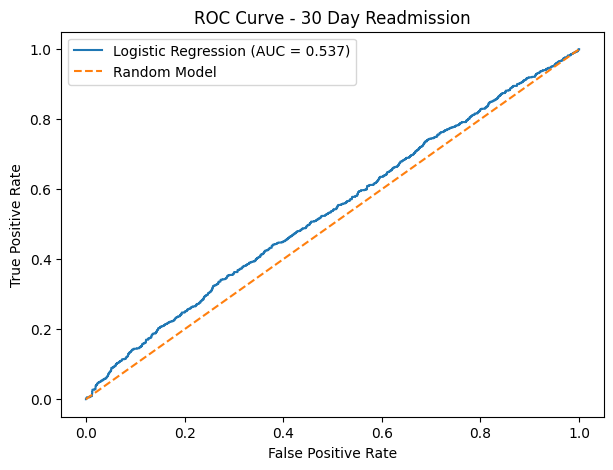

In [18]:
# Different thresholds par model ki performance ko ROC curve me dekh rahe hain
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Model")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - 30 Day Readmission")
plt.legend()
plt.show()

In [19]:
# Kitni predictions sahi aur galat hui hain, ye confusion matrix se check kar rahe hain
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[5265    0]
 [ 735    0]]


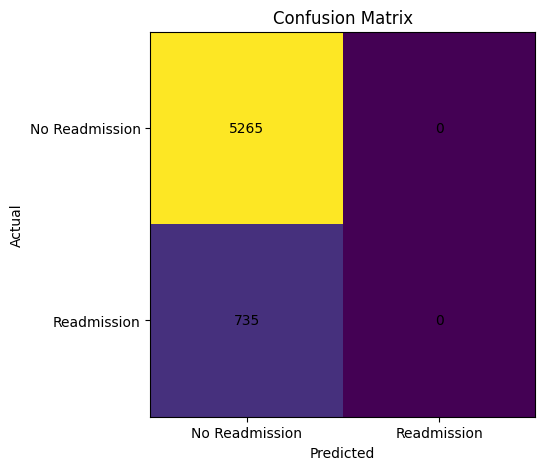

In [20]:
# Confusion matrix ko graph ke form me clearly show kar rahe hain
plt.figure(figsize=(6, 5))
plt.imshow(cm)

plt.xticks([0, 1], ["No Readmission", "Readmission"])
plt.yticks([0, 1], ["No Readmission", "Readmission"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

In [21]:
# Precision, recall aur F1-score se model ki detailed performance check kar rahe hain
print(classification_report(
    y_test,
    y_pred,
    target_names=["No Readmission", "Readmission"]
))

                precision    recall  f1-score   support

No Readmission       0.88      1.00      0.93      5265
   Readmission       0.00      0.00      0.00       735

      accuracy                           0.88      6000
     macro avg       0.44      0.50      0.47      6000
  weighted avg       0.77      0.88      0.82      6000



c:\Users\acer\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\acer\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\acer\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

In [22]:
# Model ki correct aur incorrect predictions ko alag-alag count kar rahe hain
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives  :", tp)

True Negatives : 5265
False Positives: 0
False Negatives: 735
True Positives  : 0


In [23]:
# False positive aur false negative ki rate calculate kar rahe hain
fpr_rate = fp / (fp + tn)
fnr_rate = fn / (fn + tp)

print("False Positive Rate :", round(fpr_rate, 4))
print("False Negative Rate :", round(fnr_rate, 4))

False Positive Rate : 0.0
False Negative Rate : 1.0


In [24]:
# Alag-alag probability thresholds par model ka result compare kar rahe hain
for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_test, pred)
    
    tn, fp, fn, tp = cm.ravel()
    
    print(
        f"Threshold: {threshold} | "
        f"FP: {fp} | FN: {fn} | TP: {tp} | TN: {tn}"
    )

Threshold: 0.3 | FP: 101 | FN: 714 | TP: 21 | TN: 5164
Threshold: 0.4 | FP: 16 | FN: 731 | TP: 4 | TN: 5249
Threshold: 0.5 | FP: 0 | FN: 735 | TP: 0 | TN: 5265
Threshold: 0.6 | FP: 0 | FN: 735 | TP: 0 | TN: 5265
Threshold: 0.7 | FP: 0 | FN: 735 | TP: 0 | TN: 5265


In [25]:
# Model ke features ke coefficients dekh rahe hain taaki unka effect samajh sakein
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
coefficients = model.named_steps["logistic_regression"].coef_[0]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

feature_importance["Absolute_Coefficient"] = feature_importance["Coefficient"].abs()

feature_importance.sort_values(
    "Absolute_Coefficient",
    ascending=False
).head(10)

,Feature,Coefficient,Absolute_Coefficient
301,cat__blood_pressure_119/83,1.547897,1.547897
1183,cat__blood_pressure_147/97,1.518803,1.518803
864,cat__blood_pressure_137/88,1.513280,1.513280
399,cat__blood_pressure_122/88,1.494244,1.494244
809,cat__blood_pressure_135/95,1.458217,1.458217
1252,cat__blood_pressure_150/73,1.398199,1.398199
565,cat__blood_pressure_127/99,1.338497,1.338497
597,cat__blood_pressure_129/100,1.328852,1.328852
1474,cat__blood_pressure_157/78,1.266671,1.266671
1435,cat__blood_pressure_156/70,1.257330,1.257330


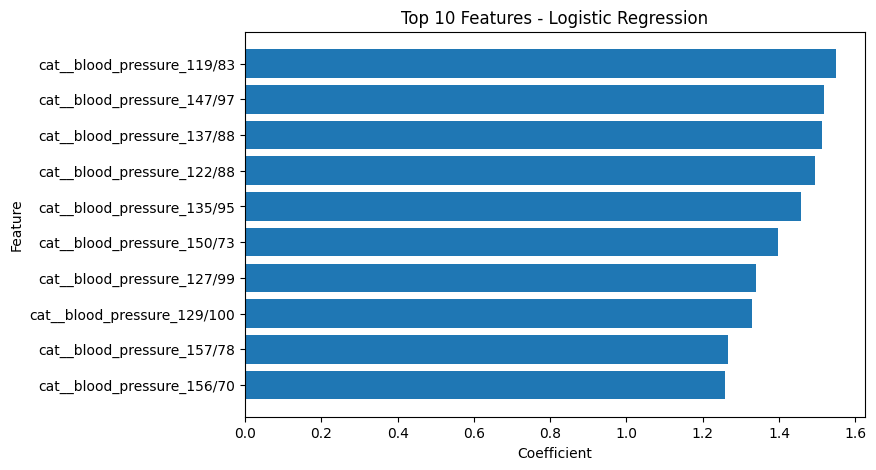

In [26]:
# Top 10 features ko graph me visualize kar rahe hain
top_features = feature_importance.sort_values(
    "Absolute_Coefficient",
    ascending=False
).head(10)

plt.figure(figsize=(8, 5))
plt.barh(top_features["Feature"], top_features["Coefficient"])

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Top 10 Features - Logistic Regression")
plt.gca().invert_yaxis()

plt.show()

In [27]:
# Model ke final results ek jagah summarize kar rahe hain
print("ROC-AUC Score:", round(auc, 4))
print("Accuracy:", round((tp + tn) / (tp + tn + fp + fn), 4))
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)
print("True Negatives:", tn)

ROC-AUC Score: 0.5373
Accuracy: 0.8775
False Positives: 0
False Negatives: 735
True Positives: 0
True Negatives: 5265


## Clinical Cost of False Positives and False Negatives

False Negative means the model predicts that a patient will not be readmitted, but the patient is actually readmitted within 30 days. This can be clinically important because a high-risk patient may miss extra monitoring or follow-up care.

False Positive means the model predicts readmission, but the patient is not actually readmitted. This may lead to unnecessary follow-up, monitoring, and use of hospital resources.

Therefore, both types of errors are important. The classification threshold can be adjusted depending on the clinical requirements and the relative cost of false negatives and false positives.

NITIN KUMAR BHATT